In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [6]:
def plot_error_distribution(df, ax=None):
    err, _ = calc_error(df)
    long = err.melt(var_name="variable", value_name="value")

    # Get color palette
    palette = sns.color_palette(n_colors=err.shape[1])
    
    # Create the violin plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))  # Erstelle nur eine neue Figur, wenn ax nicht übergeben wurde
    
    sns.violinplot(data=long, hue="variable", y="value", inner="point", palette=palette, ax=ax)

    # Draw the reference line
    ax.axhline(y=0, c="red", linestyle="--")
    ax.set_ylabel("Error")
    ax.set_ylim(-10, 10)
    # Compute mean and standard deviation
    means = err.mean(axis=0)
    sds = err.std(axis=0)

    # Create legend patches
    handles = [
        mpatches.Patch(color=palette[i], label=f"{col}: μ={means[col]:.2f}, σ={sds[col]:.2f}")
        for i, col in enumerate(err.columns)
    ]
    
    ax.legend(handles=handles, title="Mean and Std Dev", loc="best", fontsize=12)
    return ax



# Plot increase in confounding

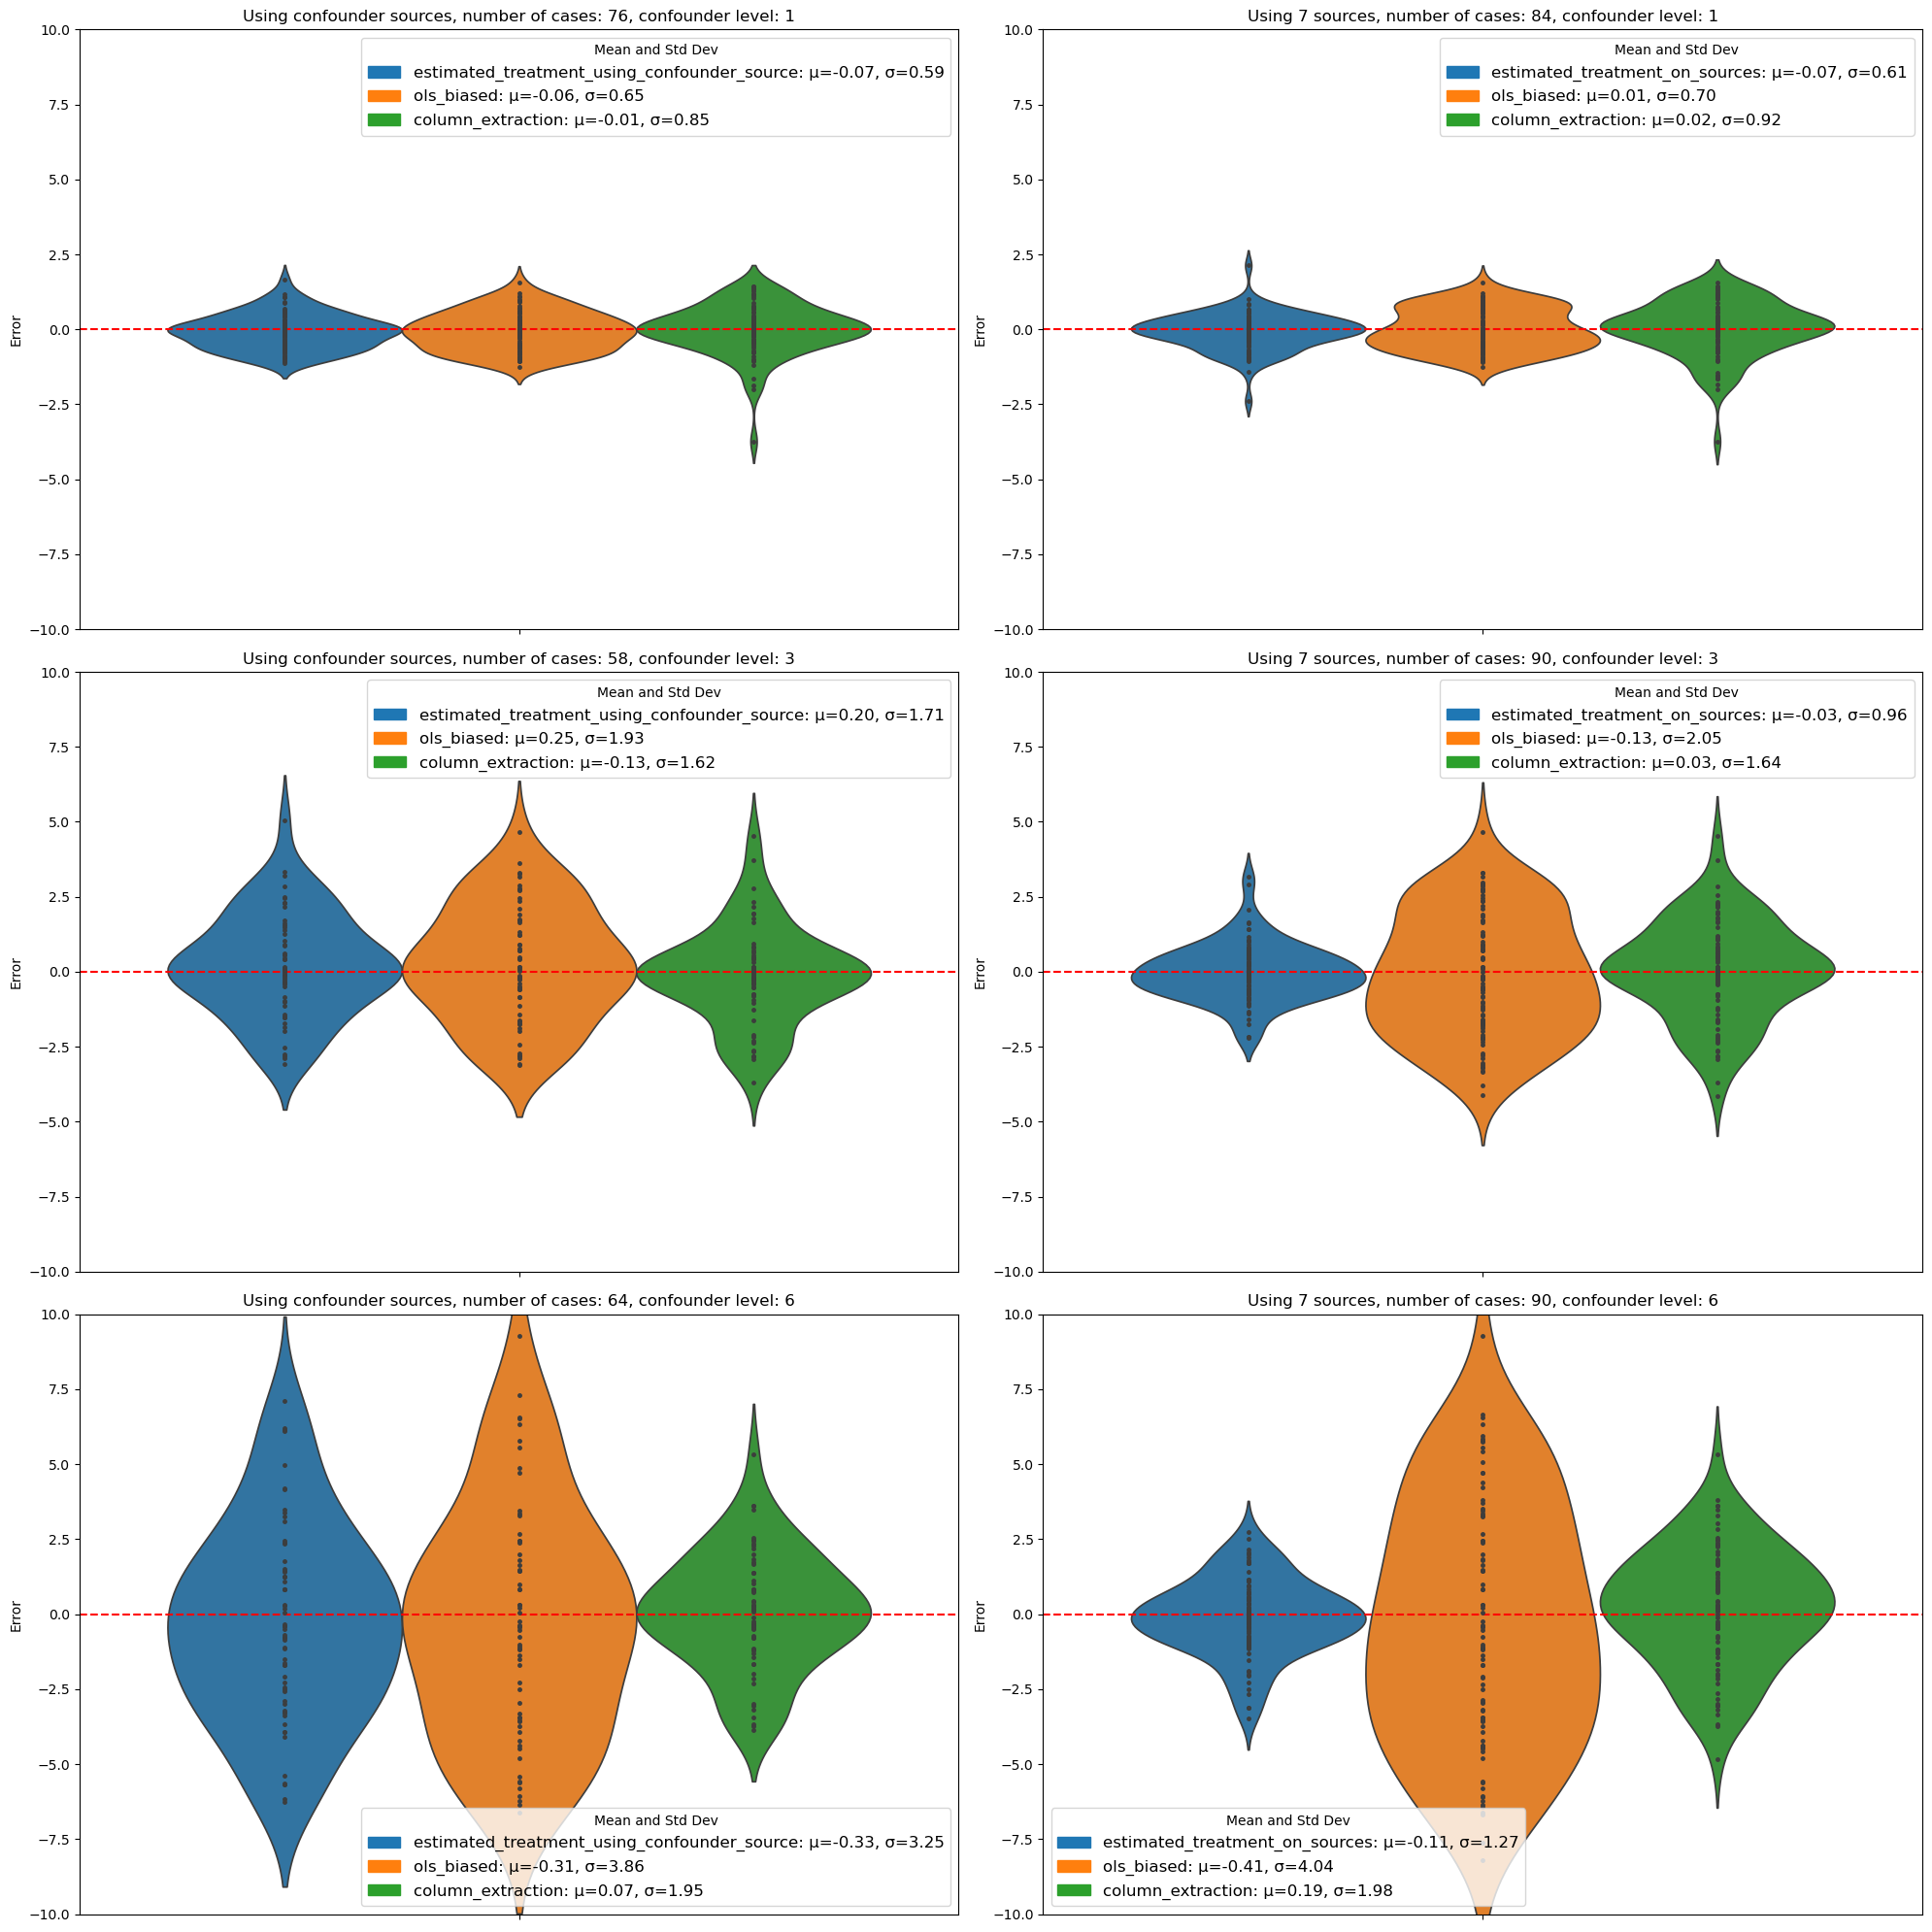

In [7]:
# Define subplot layout
fig, ax = plt.subplots(3, 2, figsize=(20, 20))
confounder_levels = [1, 3, 6]

for i, level in enumerate(confounder_levels):
    data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{level}.csv", header=0, index_col=0)
    plot_error_distribution(data1, ax[i, 0])
    ax[i, 0].set_title(f"Using confounder sources, number of cases: {data1.shape[0]}, confounder level: {level}")

    data2 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{level}.csv", header=0, index_col=0)
    plot_error_distribution(data2, ax[i, 1])
    ax[i, 1].set_title(f"Using 7 sources, number of cases: {data2.shape[0]}, confounder level: {level}")
plt.tight_layout()
plt.show()


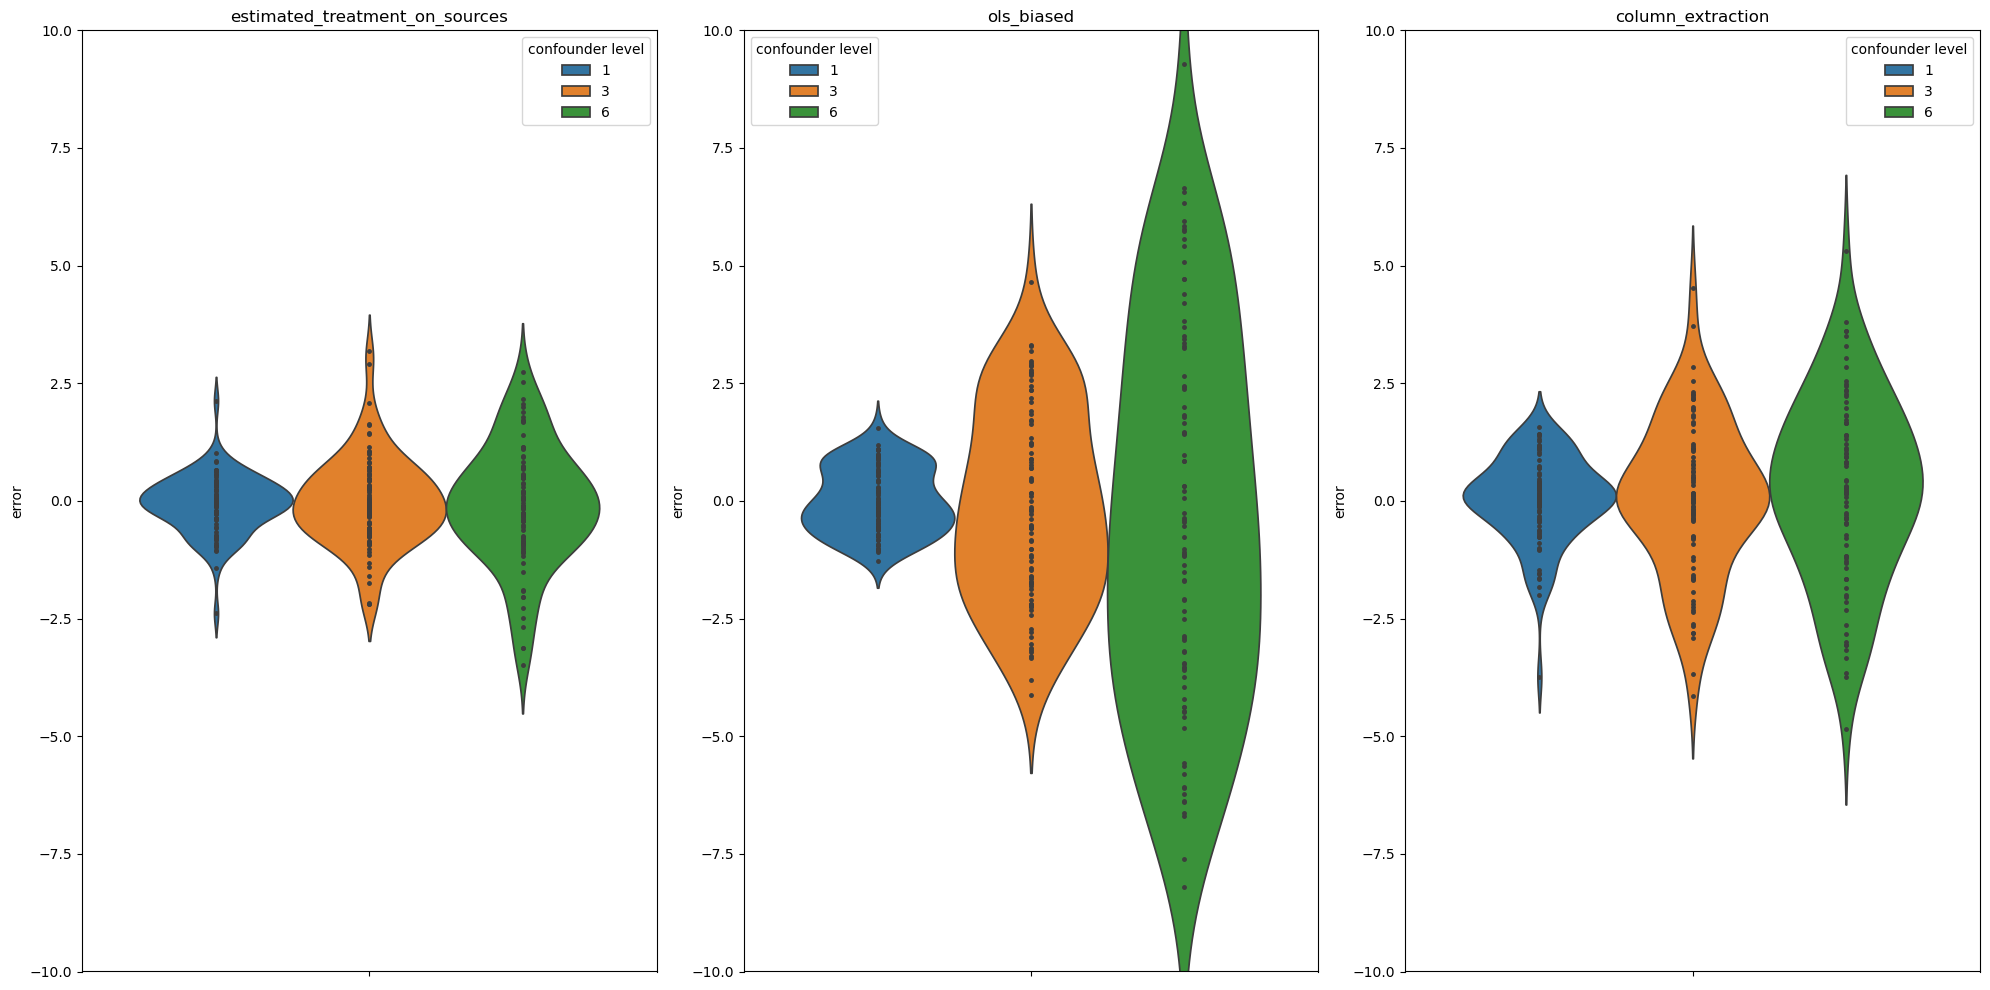

In [10]:
# plot different confounding levels in one plot one for each method
data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{1}.csv", header=0, index_col=0)
err1, seed = calc_error(data1)
data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{3}.csv", header=0, index_col=0)
err3 = calc_error(data3)[0]
data6 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_7_sources_cn_{6}.csv", header=0, index_col=0)
err6 = calc_error(data6)[0]

methods = err1.columns
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
for method in methods:
    df = pd.DataFrame({"1": err1[method], "3": err3[method], "6": err6[method]})
    long = df.melt(var_name="confounder level", value_name="error")
    sns.violinplot(data=long, hue="confounder level", y="error", ax=ax[methods.get_loc(method)], inner="point")

    ax[methods.get_loc(method)].set_title(method)
    ax[methods.get_loc(method)].set_ylim(-10, 10)
plt.tight_layout()
plt.show()


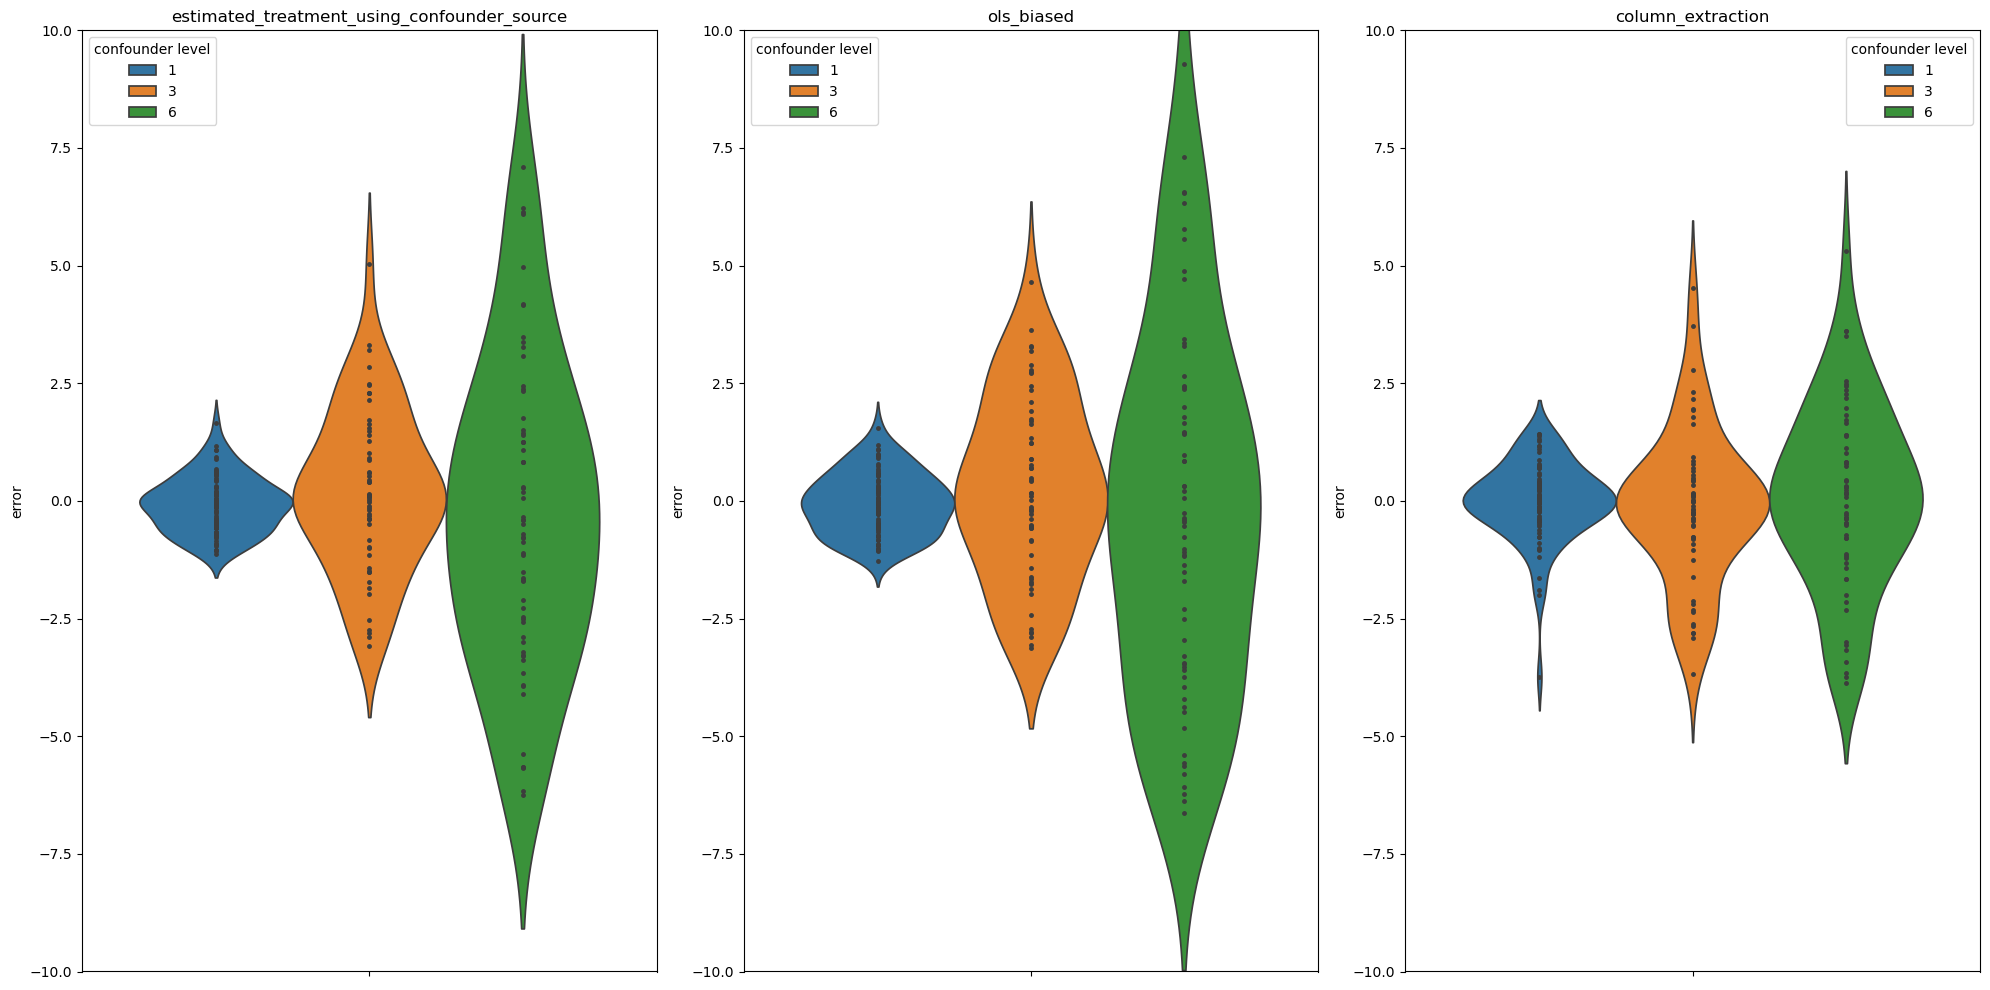

In [12]:
data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{1}.csv", header=0, index_col=0)
err1, seed = calc_error(data1)
data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{3}.csv", header=0, index_col=0)
err3 = calc_error(data3)[0]
data6 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_{6}.csv", header=0, index_col=0)
err6 = calc_error(data6)[0]

methods = err1.columns
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
for method in methods:
    df = pd.DataFrame({"1": err1[method], "3": err3[method], "6": err6[method]})
    long = df.melt(var_name="confounder level", value_name="error")
    sns.violinplot(data=long, hue="confounder level", y="error", ax=ax[methods.get_loc(method)], inner="point")
    ax[methods.get_loc(method)].set_ylim(-10, 10)

    ax[methods.get_loc(method)].set_title(method)
plt.tight_layout()
plt.show()


# Plot bounded treatment

In [22]:
data1 = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/VarEM_confounder_source_bounded_treatment.csv", header=0, index_col=0)
data2 = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/VarEM_7_sources_bounded_treatment.csv", header=0, index_col=0)

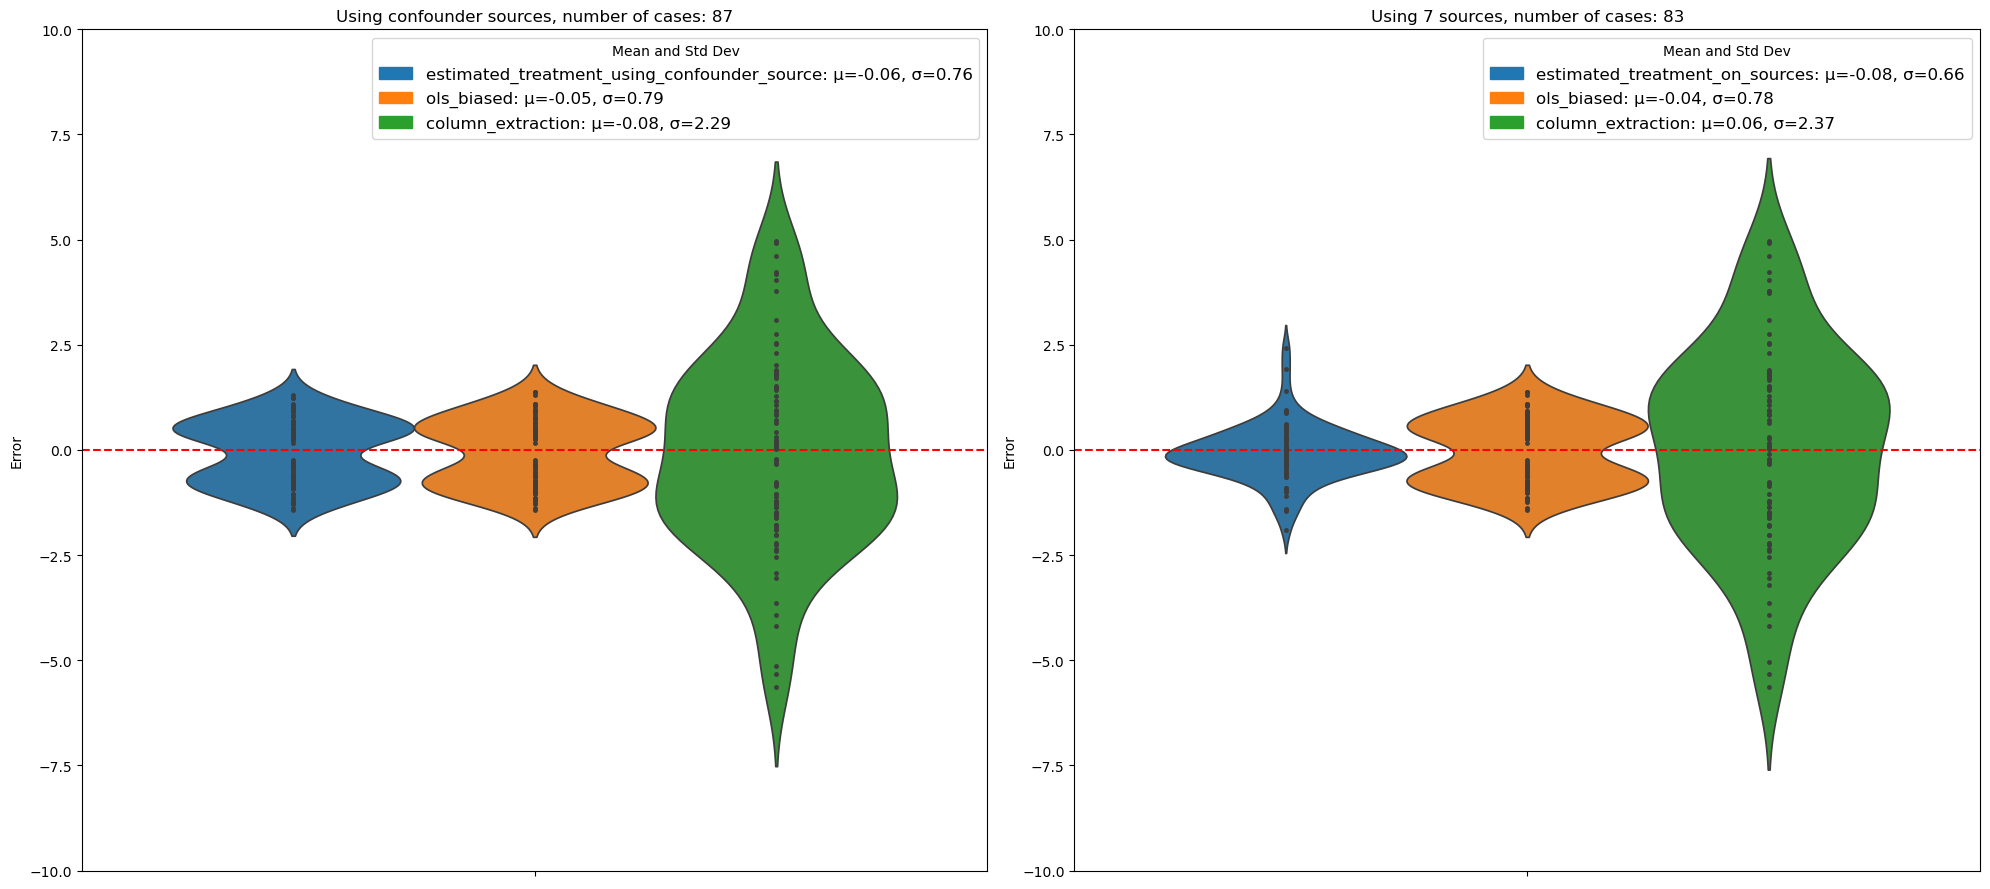

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(20,9))
plot_error_distribution(data1, ax[0])
ax[0].set_title(f"Using confounder sources, number of cases: {data1.shape[0]}")
plot_error_distribution(data2, ax[1])
ax[1].set_title(f"Using 7 sources, number of cases: {data2.shape[0]}")
plt.tight_layout()
plt.show()

# plot distributions with respect to conditioning number

In [74]:

data = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_bounded_treatment.csv", header = 0, index_col=0)
cond_number = calculate_conditioning_number("../data_generation/bounded_treatment_effect/data/true_mixing_init_flipp")

#data = pd.read_csv("../treatment_effect_estimation/treatment_effect_estimations/CausalVarEM_confounder_source_cn_6.csv", header = 0, index_col=0)
#cond_number = calculate_conditioning_number("../data_generation/different_confounding_levels/data/true_mixing_large_conf_6")



cond_df = pd.DataFrame({"seed" : [i for i in range(100)], "conditioning_number" : cond_number})

In [75]:
err, seed = calc_error(data)
df = pd.concat([err, seed], axis=1)

In [76]:
df = pd.merge(df, cond_df, on="seed").drop("seed", axis=1)
df.shape

(81, 4)

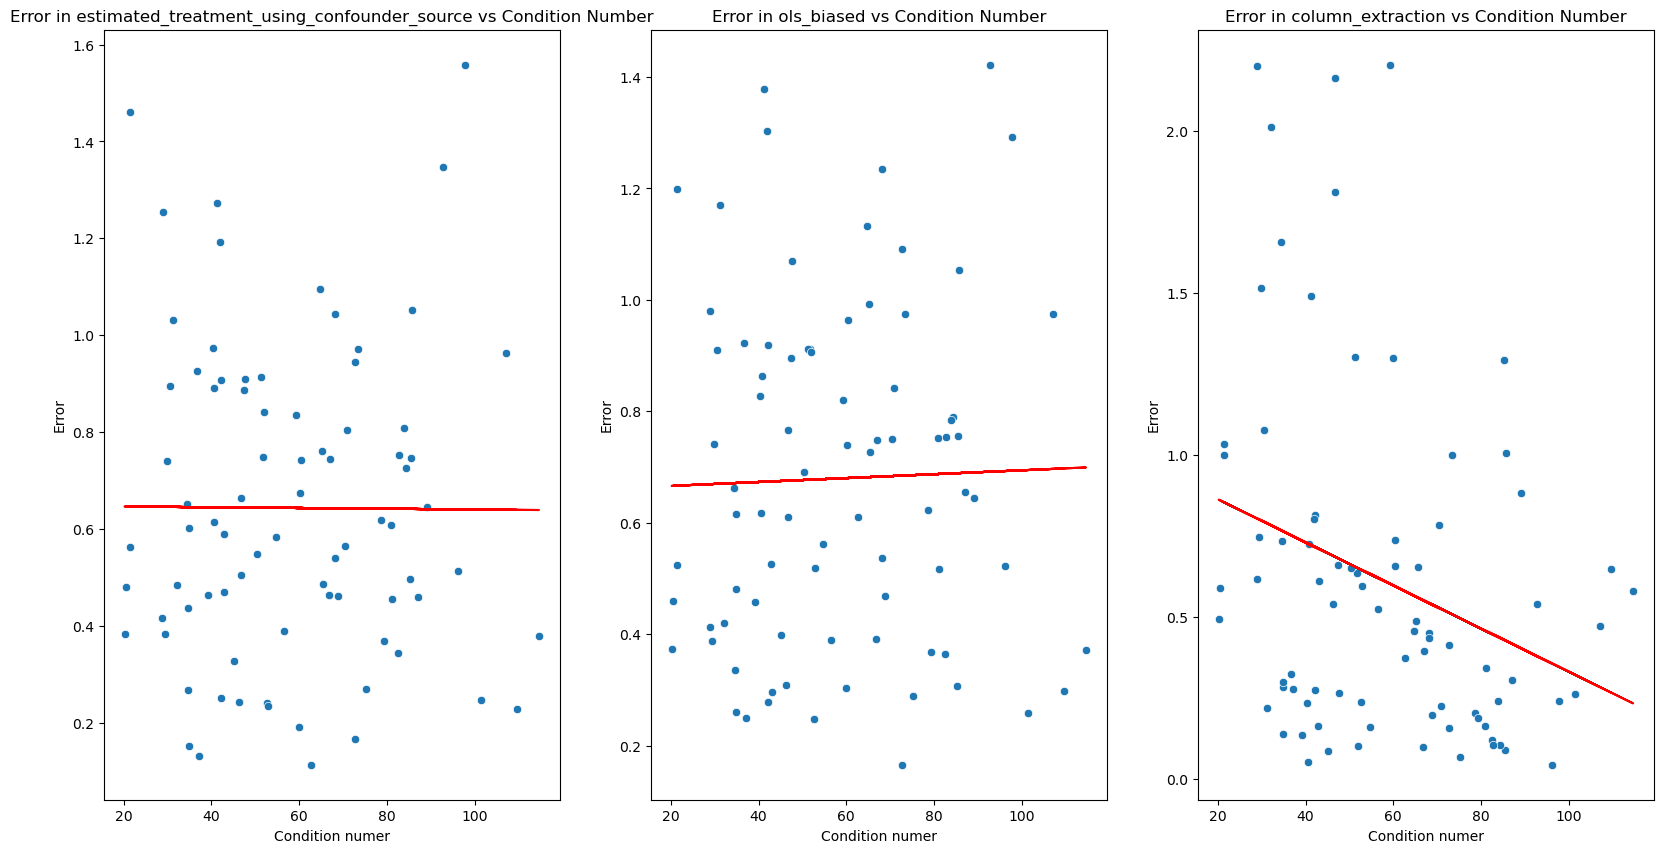

In [77]:
fig, ax= plt.subplots(1,3, figsize=(20, 10))
cond = df["conditioning_number"]
for i in range(3):
    sns.scatterplot(x=cond, y = np.abs(df.iloc[:,i]), ax=ax[i])
    ax[i].set_xlabel(f"Condition numer")
    ax[i].set_ylabel("Error")
    # linear fit
    m, b = np.polyfit(cond, np.abs(df.iloc[:,i]), 1)
    ax[i].plot(cond, m*cond + b, c="red")
    ax[i].set_title(f"Error in {df.columns[i]} vs Condition Number")
    
plt.show()


In [52]:
# differenence in mean of condition number in the two cases
seed_not_in_df = [i for i in cond_df["seed"] if i not in seed.values]


In [55]:
mean_in = cond_df[cond_df["seed"].isin(seed.values)]["conditioning_number"].mean()
mean_not_in = cond_df[cond_df["seed"].isin(seed_not_in_df)]["conditioning_number"].mean()

In [57]:
# test if the difference in mean is significant
from scipy.stats import ttest_ind
ttest_ind(cond_df[cond_df["seed"].isin(seed.values)]["conditioning_number"], cond_df[cond_df["seed"].isin(seed_not_in_df)]["conditioning_number"])

TtestResult(statistic=0.6255745858624346, pvalue=0.5330481531742122, df=98.0)